In [69]:
import pandas as pd

In [71]:
df=pd.read_csv("cyclone_prediction.csv")
df

,index,FID,YEAR,MONTH,DAY,AD_TIME,BTID,NAME,LAT,LONG,...,Sea_Surface_Temperature,Atmospheric_Pressure,Humidity,Wind_Shear,Vorticity,Latitude,Ocean_Depth,Proximity_to_Coastline,Pre_existing_Disturbance,Cyclone
0,0,2001,1957,8,8,1800Z,63,NOTNAMED,22.5,-140.0,...,27.498160,1008.521429,89.279758,13.979877,0.000020,8.119890,76.137625,1.366176,1,1
1,1,2002,1961,10,3,1200Z,116,PAULINE,22.1,-140.2,...,28.404460,1001.242177,60.823380,19.548648,0.000084,9.246782,131.821235,0.683405,1,1
2,2,2003,1962,8,29,0600Z,124,C,18.0,-140.0,...,27.216969,995.742693,77.277801,9.368437,0.000063,7.789877,181.465092,0.866362,1,1
3,3,2004,1967,7,14,0600Z,168,DENISE,16.6,-139.5,...,27.824280,1003.555279,67.986951,12.713517,0.000061,5.929008,323.395183,0.670524,1,1
4,4,2005,1972,8,16,1200Z,251,DIANA,18.5,-139.8,...,26.260206,1008.466566,98.625281,17.125960,0.000034,6.953442,357.904862,0.940152,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1995,1996,1991,8,6,1200Z,573,FEFA,18.3,-147.0,...,24.444059,1019.783538,58.691379,15.306127,0.000034,22.229769,2769.879093,1.487565,0,0
1996,1996,1997,1978,8,29,0000Z,344,MIRIAM,15.1,-145.3,...,23.049400,1017.971950,74.193806,10.104250,0.000047,25.230303,3533.586214,1.855625,0,0
1997,1997,1998,1991,8,6,1800Z,573,FEFA,18.3,-148.7,...,23.736830,1020.874352,38.880991,13.183351,0.000033,32.402860,4472.888270,1.643740,0,0
1998,1998,1999,1991,8,7,0000Z,573,FEFA,18.3,-149.9,...,24.203914,1008.284827,79.000021,16.393914,0.000037,25.639636,3081.710478,1.393481,0,0


In [73]:
print(df.head())
print(df.info())
print(df.describe())

   index   FID  YEAR  MONTH  DAY AD_TIME  BTID      NAME   LAT   LONG  ...  \
0      0  2001  1957      8    8   1800Z    63  NOTNAMED  22.5 -140.0  ...   
1      1  2002  1961     10    3   1200Z   116   PAULINE  22.1 -140.2  ...   
2      2  2003  1962      8   29   0600Z   124         C  18.0 -140.0  ...   
3      3  2004  1967      7   14   0600Z   168    DENISE  16.6 -139.5  ...   
4      4  2005  1972      8   16   1200Z   251     DIANA  18.5 -139.8  ...   

   Sea_Surface_Temperature  Atmospheric_Pressure   Humidity Wind_Shear  \
0                27.498160           1008.521429  89.279758  13.979877   
1                28.404460           1001.242177  60.823380  19.548648   
2                27.216969            995.742693  77.277801   9.368437   
3                27.824280           1003.555279  67.986951  12.713517   
4                26.260206           1008.466566  98.625281  17.125960   

   Vorticity  Latitude  Ocean_Depth  Proximity_to_Coastline  \
0   0.000020  8.119890 

In [75]:
columns_to_drop = ['index', 'FID', 'AD_TIME', 'BTID', 'NAME', 'CAT', 'BASIN', 'Shape_Leng']
df_clean = df.drop(columns=columns_to_drop)
print(df_clean.isnull().sum())

YEAR                        0
MONTH                       0
DAY                         0
LAT                         0
LONG                        0
WIND_KTS                    0
PRESSURE                    0
Sea_Surface_Temperature     0
Atmospheric_Pressure        0
Humidity                    0
Wind_Shear                  0
Vorticity                   0
Latitude                    0
Ocean_Depth                 0
Proximity_to_Coastline      0
Pre_existing_Disturbance    0
Cyclone                     0
dtype: int64


In [85]:
from sklearn.model_selection import train_test_split
x=df[['Sea_Surface_Temperature','Atmospheric_Pressure','Humidity','Wind_Shear','Vorticity']]
y=df['Cyclone']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

In [87]:
!pip install xgboost
from xgboost import XGBClassifier
model = XGBClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    eval_metric='logloss',
    random_state=42
)
model.fit(x_train, y_train)
import pickle

with open("xgb_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [171]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)  
xgb_model = XGBClassifier( eval_metric='logloss')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb_model, x_scaled, y, cv=cv, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean accuracy:", np.mean(scores))

Cross-validation scores: [0.975  0.99   0.98   0.985  0.9925]
Mean accuracy: 0.9844999999999999


In [89]:
xgb_probs = model.predict_proba(x_test)[:, 1]

In [91]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
fpr, tpr, _ = roc_curve(y_test, xgb_probs)
roc_auc = auc(fpr, tpr)

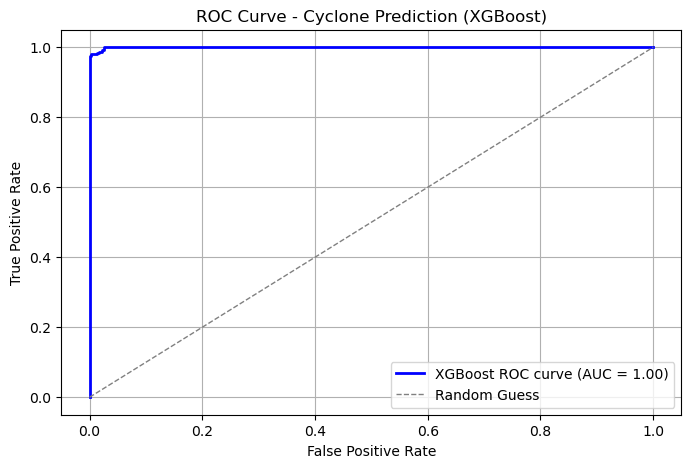

In [93]:
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'XGBoost ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Cyclone Prediction (XGBoost)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [51]:
xgb_probs = model.predict_proba(x_test)[:, 1]
print("Sample predicted probabilities:", xgb_probs[:20])

Sample predicted probabilities: [0.9921698  0.0073975  0.9921698  0.99134034 0.9863674  0.0073975
 0.99208343 0.9921698  0.01049512 0.96323043 0.0390994  0.0073975
 0.98899174 0.9778917  0.0073975  0.9475455  0.99174386 0.9834536
 0.9868858  0.98899174]


In [53]:
print(df_clean.corr()['Cyclone'].sort_values(ascending=False))

Cyclone                     1.000000
Pre_existing_Disturbance    1.000000
LONG                        0.851064
Sea_Surface_Temperature     0.741450
Humidity                    0.675290
Vorticity                   0.526510
PRESSURE                    0.151744
LAT                         0.113048
YEAR                        0.057170
MONTH                       0.004002
WIND_KTS                   -0.006739
DAY                        -0.035424
Wind_Shear                 -0.575731
Latitude                   -0.642161
Proximity_to_Coastline     -0.662316
Atmospheric_Pressure       -0.743838
Ocean_Depth                -0.760751
Name: Cyclone, dtype: float64


<Axes: xlabel='Cyclone', ylabel='count'>

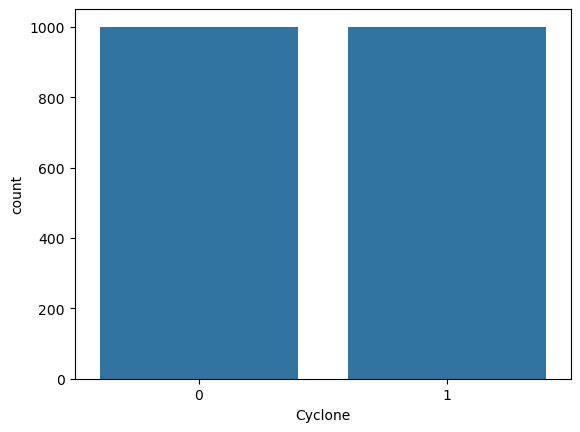

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Cyclone', data=df_clean)

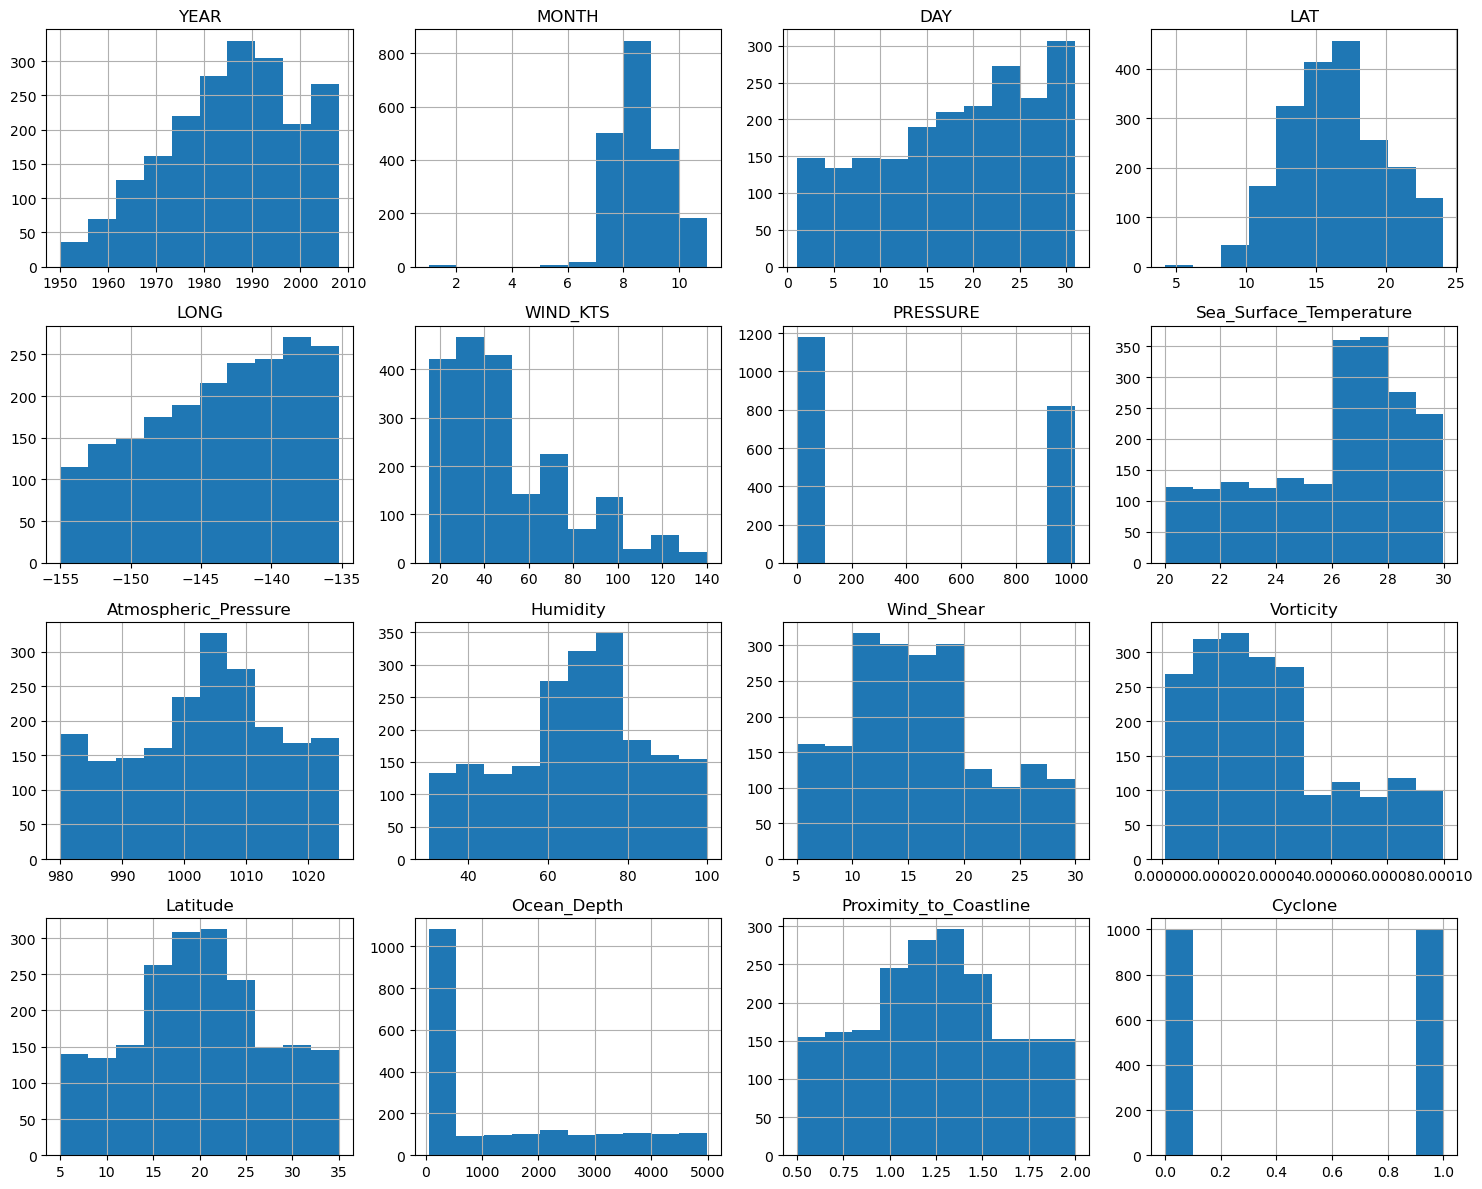

In [97]:
df_clean.hist(figsize=(15, 12))
plt.tight_layout()
plt.show()

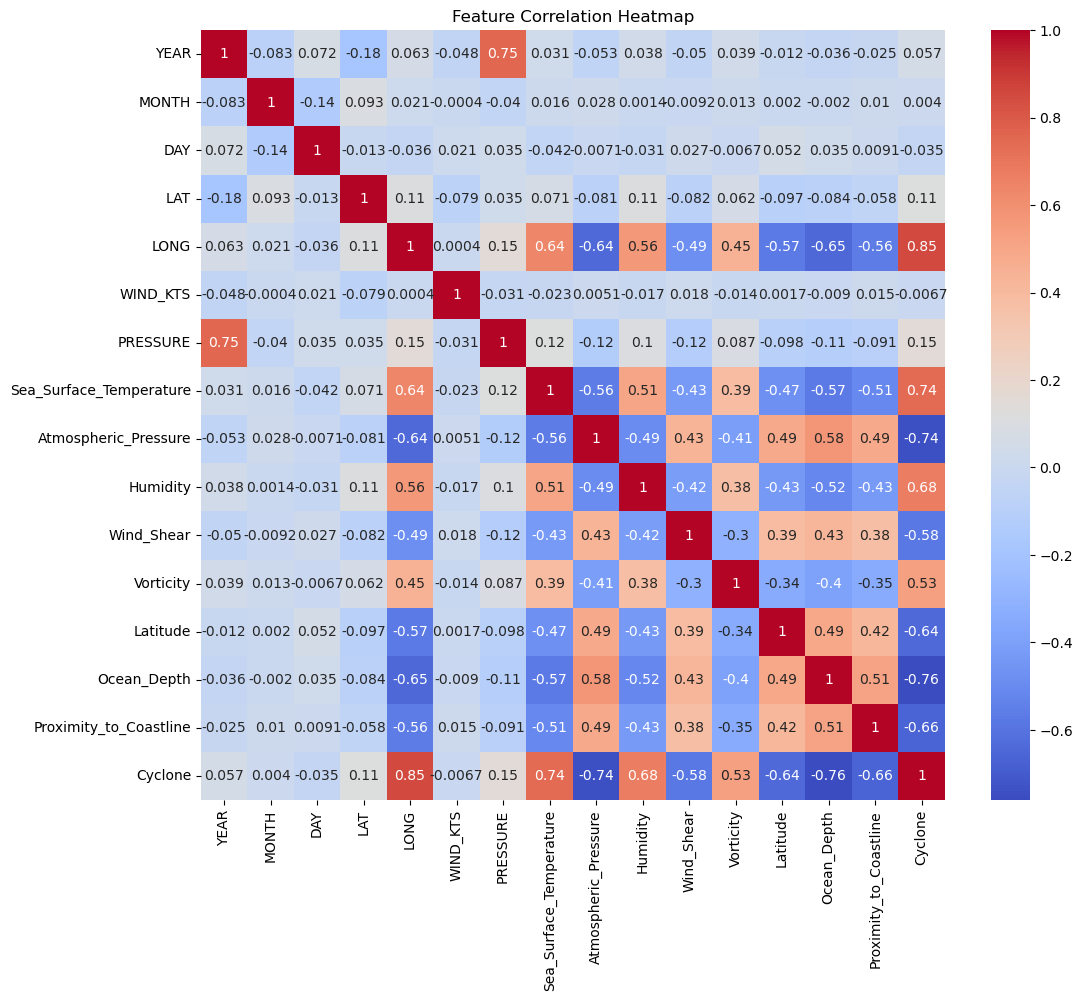

In [99]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

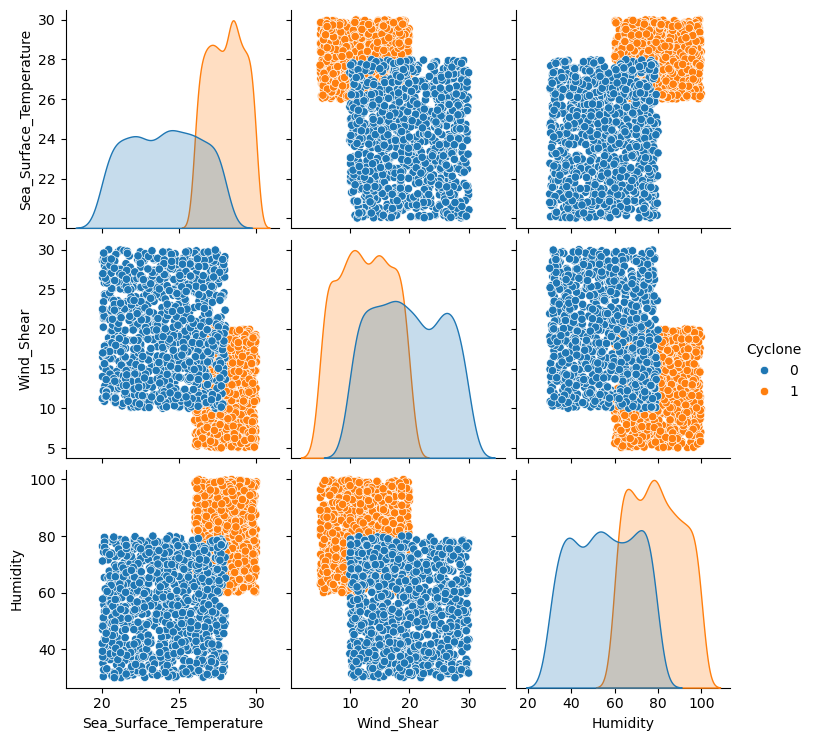

In [101]:
sns.pairplot(df_clean[['Sea_Surface_Temperature', 'Wind_Shear', 'Humidity', 'Cyclone']], hue='Cyclone')

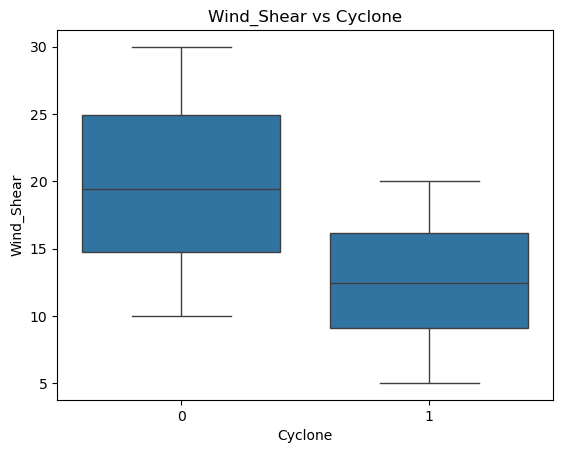

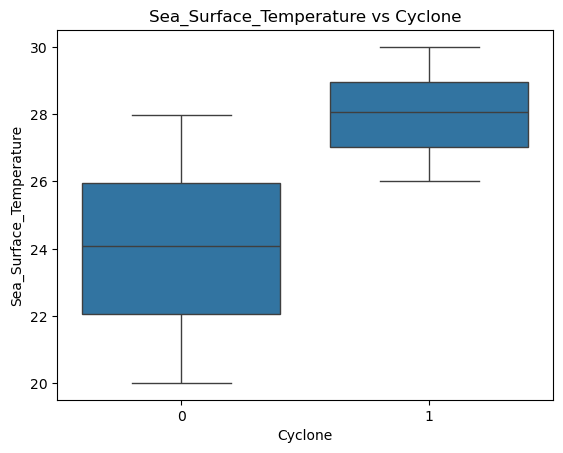

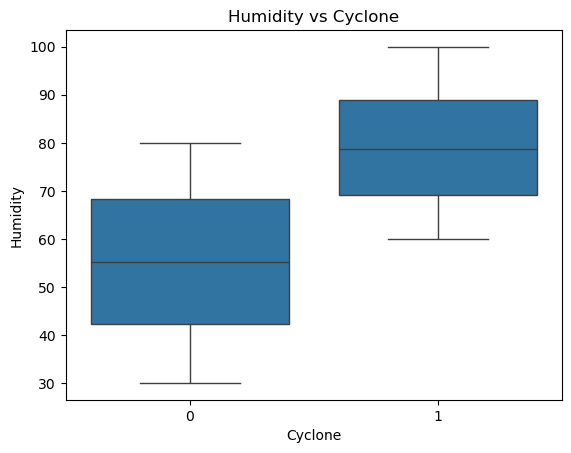

In [103]:
features = ['Wind_Shear', 'Sea_Surface_Temperature', 'Humidity']
for feature in features:
    sns.boxplot(x='Cyclone', y=feature, data=df_clean)
    plt.title(f'{feature} vs Cyclone')
    plt.show()

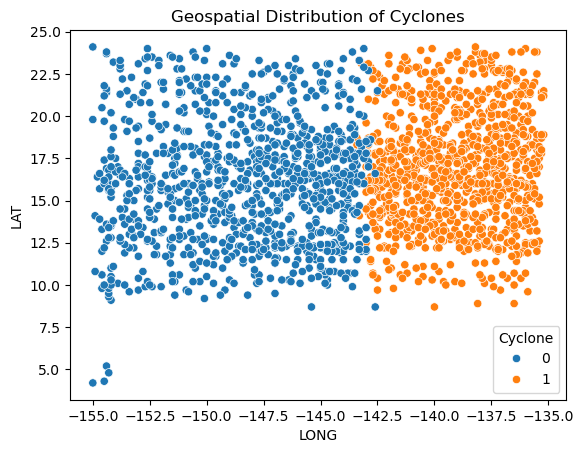

In [105]:
sns.scatterplot(x='LONG', y='LAT', hue='Cyclone', data=df_clean)
plt.title("Geospatial Distribution of Cyclones")
plt.show()

In [107]:
from sklearn.metrics import accuracy_score,classification_report
y_pred = model.predict(x_test)
print(" Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
y_pred_train = model.predict(x_train)
train_accuracy = accuracy_score(y_train, y_pred_train)
print("Training Accuracy:", train_accuracy)

 Test Accuracy: 0.9816666666666667
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       307
           1       0.98      0.99      0.98       293

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600

Training Accuracy: 0.9907142857142858


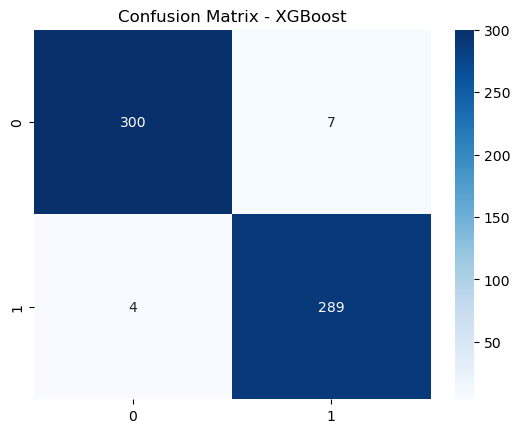

In [161]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [100]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree

In [102]:
x=df[['Sea_Surface_Temperature','Atmospheric_Pressure','Humidity','Wind_Shear','Vorticity']]
y=df['Cyclone']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)
model=DecisionTreeClassifier(max_depth=3,random_state=0)
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [111]:
dt_probs = model.predict_proba(x_test)[:, 1]

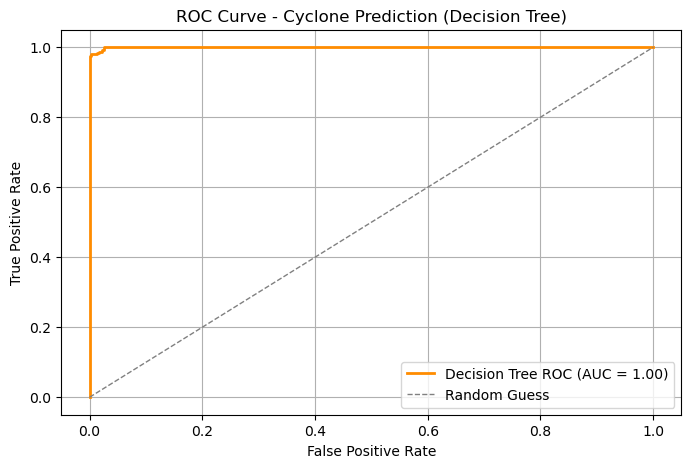

In [113]:
from sklearn.metrics import roc_curve, auc
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
auc_dt = auc(fpr_dt, tpr_dt)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'Decision Tree ROC (AUC = {auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Cyclone Prediction (Decision Tree)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [115]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
print(" Test Accuracy:", accuracy_score(y_test, y_pred))

 Test Accuracy: 0.9816666666666667


In [117]:
y_pred_train = model.predict(x_train)
train_acc = accuracy_score(y_train, y_pred_train)
print("Training Accuracy (Decision Tree):", train_acc)

Training Accuracy (Decision Tree): 0.9907142857142858


In [108]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98       306
           1       0.95      1.00      0.98       294

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



Text(0.5, 1.0, 'Confusion Matrix - DecisionTree')

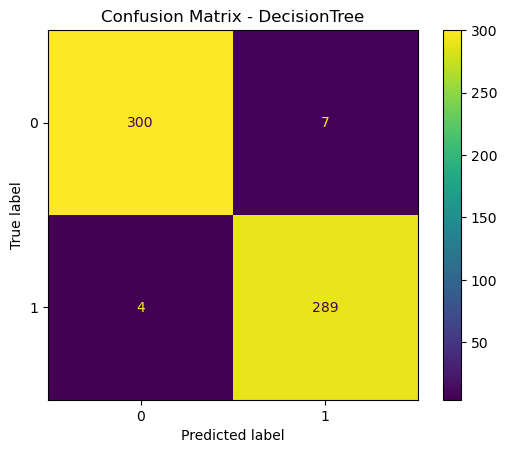

In [165]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title('Confusion Matrix - DecisionTree')

In [143]:
from sklearn.svm import SVC

SVM Accuracy: 0.9066666666666666
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.87      0.90       307
           1       0.87      0.95      0.91       293

    accuracy                           0.91       600
   macro avg       0.91      0.91      0.91       600
weighted avg       0.91      0.91      0.91       600



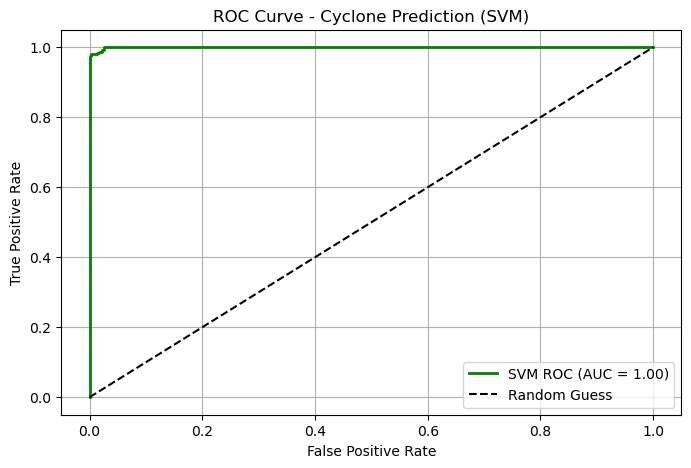

In [145]:
from sklearn.metrics import accuracy_score, classification_report
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(x_train, y_train)
y_pred_svm = svm_model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
from sklearn.metrics import roc_curve, auc

svm_probs = model.predict_proba(x_test)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
auc_svm = auc(fpr_svm, tpr_svm)
plt.figure(figsize=(8, 5))
plt.plot(fpr_svm, tpr_svm, color='green', lw=2, label=f'SVM ROC (AUC = {auc_svm:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Cyclone Prediction (SVM)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [147]:
y_train_pred = svm_model.predict(x_train)
train_acc = accuracy_score(y_train, y_train_pred)
print("Training Accuracy (SVM):", train_acc)

Training Accuracy (SVM): 0.9192857142857143


<Figure size 600x500 with 0 Axes>

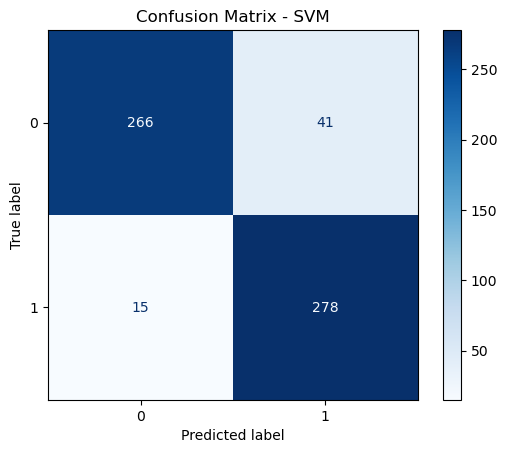

In [159]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
svm_preds = svm_model.predict(x_test)
cm = confusion_matrix(y_test, svm_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - SVM')
plt.grid(False)
plt.show()

In [173]:
!dir

 Volume in drive C is Windows-SSD
 Volume Serial Number is 2CD7-88B3

 Directory of C:\Users\KIIT

22-06-2025  00:54    <DIR>          .
07-06-2023  02:37    <DIR>          ..
20-06-2025  11:30    <DIR>          .anaconda
22-06-2025  00:54    <DIR>          .conda
20-06-2025  11:29               146 .condarc
20-06-2025  11:29    <DIR>          .continuum
20-06-2025  16:02    <DIR>          .ipynb_checkpoints
20-06-2025  11:30    <DIR>          .ipython
20-06-2025  14:27    <DIR>          .jupyter
20-06-2025  12:05    <DIR>          .matplotlib
14-06-2025  08:10    <DIR>          .ms-ad
22-05-2025  12:17    <DIR>          .netbeans-derby
09-04-2025  01:09                 0 .node_repl_history
11-03-2025  09:48               174 .packettracer
25-03-2025  18:07    <DIR>          .VirtualBox
09-09-2023  00:58    <DIR>          .vscode
12-05-2025  19:28    <DIR>          anaconda3
07-05-2025  23:13    <DIR>          anaconda4
28-01-2025  11:01    <DIR>          anaconda_projects
12-05-2025  

In [175]:
import joblib

joblib.dump(model, "cyclone_model_xgb.pkl")

['cyclone_model_xgb.pkl']